<a href="https://colab.research.google.com/github/aminrafi394/quera-AI-first-project/blob/main/prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
from google.colab import drive
import pandas as pd

drive.mount("/content/drive")

data_frame_path = "/content/drive/MyDrive/Divar.csv"

data_frame = pd.read_csv(data_frame_path)

data_frame.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_36340/2932671274.py:8: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(data_frame_path)


,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,residential-rent,apartment-rent,ahvaz,mellirah,2024-09-01 00:00:00,NaN,اپارتمان ۱۰۰متری واحد جلو دارای دو اتاق خواب ک...,اپارتمان ۱۰۰متری ملی راه واحد جلو,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,commercial-rent,office-rent,kermanshah,NaN,2024-11-01 00:00:00,NaN,♦مشاورین املاک سیب♦\n✅️کد:G۱۰۵\n♦با سالها سابق...,واحداداری ۸۰متری ۲۲بهمن(برق),مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
8,8,residential-sell,apartment-sell,mahdasht-city,NaN,2024-06-01 00:00:00,مشاور املاک,با سلام\n\nاملاک بزرگ اتحاد با ۲شعبه فعال با ف...,۷۸متری دوبحرنورگیر بازسازی شده شیک سندتک برگ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.712364,50.794781,500.0
9,9,residential-sell,apartment-sell,mashhad,faramarzabbasi,2024-10-01 00:00:00,NaN,اول رسالت فرد نزدیک به حاشیه فرامرز .. ساکنین...,متراژ ۸۰ متر فرامرز نزدیک حاشیه,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We make a copy of the main data frame.

In [65]:
cp_data_frame = data_frame.copy()


cp_data_frame["construction_year"].isna().sum()

np.int64(184172)

First step is to get the houses with the price_value and remove the rent values.

In [49]:
rent_values = cp_data_frame["rent_value"].isna()
cp_data_frame = cp_data_frame[rent_values]
cp_data_frame.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
8,8,residential-sell,apartment-sell,mahdasht-city,NaN,2024-06-01 00:00:00,مشاور املاک,با سلام\n\nاملاک بزرگ اتحاد با ۲شعبه فعال با ف...,۷۸متری دوبحرنورگیر بازسازی شده شیک سندتک برگ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.712364,50.794781,500.0


As we know the number of the lines with the Nan city_slug is less than 10 so we remove them.


In [76]:
cp_data_frame = cp_data_frame.dropna(subset=["city_slug"])
cp_data_frame["location_latitude"].isna().sum()

np.int64(344390)

In this part we want to get the effective feature and do some feature negineering.

In [51]:

cp_data_frame = cp_data_frame[["city_slug", "price_value", "land_size", "building_size", "rooms_count", "has_warehouse", "has_parking", "location_latitude", "location_longitude"]]

cp_data_frame.rooms_count.value_counts()

,count
rooms_count,
دو,249573
یک,102019
سه,88311
بدون اتاق,30525
چهار,15174
پنج یا بیشتر,9279


In this part we split the train and the test data.


In [52]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(cp_data_frame, test_size=0.2, random_state=42)

As you can see the informations in the rooms_count are in the Persian language so we map the data into English.

In [53]:
from sklearn.preprocessing import FunctionTransformer

def room_count_persian(data_frame : pd.DataFrame) -> pd.DataFrame:
  map_rooms_count = {
    "دو" : 2,
    "یک" : 1,
    "سه" : 3,
    "بدون اتاق" : 0,
    "چهار" : 4,
    "پنج یا بیشتر" : 5
  }
  data_frame["rooms_count"] = data_frame["rooms_count"].map(map_rooms_count)
  return data_frame

room_count_transformer = FunctionTransformer(room_count_persian)
train_data = room_count_transformer.transform(train_data)
test_data = room_count_transformer.transform(test_data)


train_data.head()


,city_slug,price_value,land_size,building_size,rooms_count,has_warehouse,has_parking
460100,varamin-city,1.550000e+09,NaN,104.0,NaN,NaN,NaN
326068,tehran,NaN,NaN,60.0,1.0,NaN,NaN
452207,chamestan,1.500000e+09,220.0,120.0,3.0,True,True
853696,tehran,2.320000e+09,NaN,44.0,1.0,False,False
74135,abadan,NaN,NaN,NaN,NaN,NaN,NaN


In this part we rank the deed_type and turn them into numbers

In [ ]:
def deed_type_number(data_frame : pd.DataFrame):
  map_deed_type = {
      "single_page" : 5,
      "multi_page" : 4,
      "written_agreement" : 3,
      "other" : 2,
      "unselect" : 1
  }

In this part we ant to fill the Nan values fo the building size.
So, at first we group the houses based on teh city_slug
Then we fill it with the median of each city

In [54]:
from sklearn.base import BaseEstimator, TransformerMixin

class fill_building_size(BaseEstimator, TransformerMixin):
    def __init__(self, group_col: str = "city_slug", target_col: str = "building_size", downcast: bool = True):
        self.group_col = group_col
        self.target_col = target_col
        self.downcast = downcast
        self.group_medians_ = {}
        self.global_median_ = None

    def fit(self, data_frame: pd.DataFrame, y=None):
        # calculating global median.
        self.global_median_ = data_frame[self.target_col].median()

        # calculating the median of each group based in the city_slug.
        self.group_medians_ = (
            data_frame.groupby(self.group_col)[self.target_col]
            .median()
            .to_dict()
        )
        return self

    def transform(self, data_frame: pd.DataFrame) -> pd.DataFrame:
        data_frame = data_frame.copy()

        # Mapping
        group_imputed = data_frame[self.group_col].map(self.group_medians_)

        # filling
        data_frame[self.target_col] = data_frame[self.target_col].fillna(group_imputed)

        # Fill the left overs with global Nan.
        data_frame[self.target_col] = data_frame[self.target_col].fillna(self.global_median_)

        return data_frame

building_imputer = fill_building_size(group_col="city_slug", target_col="land_size", downcast=True)

train_data = building_imputer.fit_transform(train_data)
test_data = building_imputer.transform(test_data)

In this part we fill the Nan values of the land_size with the median of eaech city (same as the building size) but we must be care full to remove the lines which the building size is bugger than the land size.

In [55]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class fill_land_size(BaseEstimator, TransformerMixin):
    def __init__(self, group_col: str = "city_slug", target_col: str = "land_size", downcast: bool = True):
        self.group_col = group_col
        self.target_col = target_col
        self.downcast = downcast
        self.group_medians_ = {}
        self.global_median_ = None

    def fit(self, data_frame: pd.DataFrame, y=None):
        # global median
        self.global_median_ = data_frame[self.target_col].median()

        # grouped median based on the city_slug.
        self.group_medians_ = (
            data_frame.groupby(self.group_col)[self.target_col]
            .median()
            .to_dict()
        )
        return self

    def transform(self, data_frame: pd.DataFrame) -> pd.DataFrame:
        data_frame = data_frame.copy()

        # make a map imputer to fit
        group_imputed = data_frame[self.group_col].map(self.group_medians_)

        # fill with the map.
        data_frame[self.target_col] = data_frame[self.target_col].fillna(group_imputed)
        data_frame[self.target_col] = data_frame[self.target_col].fillna(self.global_median_)

        return data_frame

imputer = fill_land_size(group_col="city_slug", target_col="land_size", downcast=True)

train_data = imputer.fit_transform(train_data)
test_data = imputer.transform(test_data)

invalid_train_rows = train_data["building_size"] > train_data["land_size"]
train_data = train_data.loc[~invalid_train_rows]
invalid_train_rows = test_data["building_size"] > test_data["land_size"]
test_data = test_data.loc[~invalid_train_rows]

In this part we fil the Nan values based on the mode of the rooms_count grouped by city and building size.

In [56]:
def building_size_patintion(data_frame : pd.DataFrame):
    df = data_frame.copy()

    df.loc[df["building_size"] < 100, "building_size_level"] = "Low"
    df.loc[(df["building_size"] >= 100) & (df["building_size"] < 200), "building_size_level"] = "Medium"
    df.loc[df["building_size"] >= 200, "building_size_level"] = "High"

    return df

building_size_patintion = FunctionTransformer(building_size_patintion)
train_data = building_size_patintion.transform(train_data)
test_data = building_size_patintion.transform(test_data)

train_data.columns

Index(['city_slug', 'price_value', 'land_size', 'building_size', 'rooms_count',
       'has_warehouse', 'has_parking', 'building_size_level'],
      dtype='object')

In [57]:
from sklearn.base import BaseEstimator, TransformerMixin

class fill_room_count(BaseEstimator, TransformerMixin):
    def __init__(self, target_col: str = "rooms_count", dtype: str = "int8"):
        self.target_col = target_col
        self.dtype = dtype
        self.group_mode_ = {}
        self.city_median_ = {}
        self.global_median_ = None

    def fit(self, data_frame: pd.DataFrame, y=None):
        # temp eliminations to calculate the numbers(with Nan we can not do it)
        valid_mask = data_frame[self.target_col].notna()
        df_valid = data_frame.loc[valid_mask]

        # Calculating the numbers based on the city_slug and building_size_level
        mode_series = (
            df_valid.groupby(["city_slug", "building_size_level"])[self.target_col]
            .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
            .dropna()
        )
        self.group_mode_ = mode_series.to_dict()

        # Calculating the median based on the city for the second layer of filling the Nan.
        self.city_median_ = (
            df_valid.groupby("city_slug")[self.target_col]
            .median()
            .to_dict()
        )
        # The global median for the ;ast layer.
        self.global_median_ = df_valid[self.target_col].median()

        return self

    def transform(self, data_frame: pd.DataFrame) -> pd.DataFrame:
        data_frame = data_frame.copy()

        # Layer one.
        group_keys = list(zip(data_frame["city_slug"], data_frame["building_size_level"]))
        mode_imputed = pd.Series(group_keys, index=data_frame.index).map(self.group_mode_)
        data_frame[self.target_col] = data_frame[self.target_col].fillna(mode_imputed)

        # Layer two
        city_imputed = data_frame["city_slug"].map(self.city_median_)
        data_frame[self.target_col] = data_frame[self.target_col].fillna(city_imputed)

        # Third Layer.
        data_frame[self.target_col] = data_frame[self.target_col].fillna(self.global_median_)

        # Rounding.
        data_frame[self.target_col] = np.round(data_frame[self.target_col]).astype(self.dtype)

        return data_frame

room_imputer = fill_room_count(target_col="rooms_count", dtype="int8")

train_data = room_imputer.fit_transform(train_data)
test_data = room_imputer.transform(test_data)


In this part we want to full fill the has_warehouse part.
The mian logic is that if th ehouse had a parking orwarehouse the seller would say it to incearse the house price if it is Nan or missed it means the it should be filled with  0.


In [58]:
train_data["has_parking"] = train_data["has_parking"].fillna(0).astype("int8")
test_data["has_parking"] = test_data["has_parking"].fillna(0).astype("int8")
test_data["has_warehouse"] = test_data["has_warehouse"].fillna(0).astype("int8")
train_data["has_warehouse"] = train_data["has_warehouse"].fillna(0).astype("int8")

In this part we remove the unnccery feature like city_slug and building_size_level and remove the Nan values of the price_value.

In [59]:
train_data = train_data.dropna(subset=["price_value"])
test_data = test_data.dropna(subset=["price_value"])

train_data = train_data.drop(columns=["building_size_level","city_slug"])
test_data = test_data.drop(columns=["building_size_level","city_slug"])


train_x = train_data.drop(columns=["price_value"])
train_y = train_data["price_value"]

test_x = test_data.drop(columns=["price_value"])
test_y = test_data["price_value"]


<Axes: >

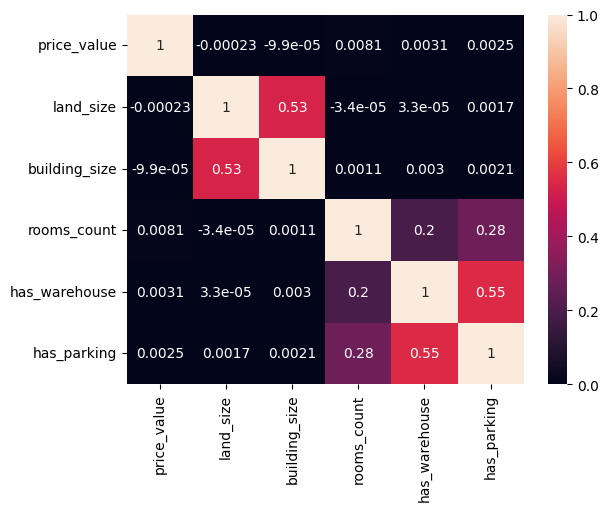

In [68]:
corrolation = train_data.corr()
sns.heatmap(
    corrolation,
    annot = True
)

Make validation set.

In [60]:
from sklearn.model_selection import train_test_split

train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size=0.2, random_state=42)

train_y.isna()

,price_value
47008,False
60420,False
533228,False
430975,False
450068,False
...,...
300248,False
970485,False
456830,False
525463,False


In this case we use a simple xgboost to test our preproccessing.

In [61]:
!pip install xgboost

In [69]:

from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import  XGBRegressor

forest_model = XGBRegressor()
forest_model.fit(train_x, train_y)

y_prediction = forest_model.predict(val_x)

print(f"MAE : {mean_absolute_error(y_true=val_y, y_pred=y_prediction)}")
print(f"r2-score :  {r2_score(y_true=val_y, y_pred=y_prediction)}")

MAE : 22101322041.12238
r2-score :  -0.1590833521824051
